In [1]:
import os, sys

# Notebooks live in Jupyters/, code lives in src/  ->  always run from the project root
if os.path.basename(os.getcwd()) == "Jupyters":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
assert os.path.exists("olist.db"), f"olist.db not found in {os.getcwd()} - launch Jupyter from the project root"

import pandas as pd
from IPython.display import Image, display
from src.data_loader import get_connection

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
conn = get_connection()  
from src.basket_analysis import *

##  Build baskets 
before starting mining

In [2]:
baskets = load_category_baskets(conn)
coverage = basket_coverage(conn, baskets)
coverage

{'orders_with_items': 98666,
 'multi_item_orders': 9803,
 'multi_item_pct': 9.94,
 'categorized_orders': 97256,
 'multi_category_orders': 726,
 'multi_category_pct': 0.75}

Only 10% of orders have more than one item and only 0.75% span two or more categories.
 category pairs are rare in Olist.

## Mine rules on multi-category baskets

In [3]:
rules = mine_category_rules(baskets, min_count=10)
print(len(rules), "rules")
display(rules.round(3).head(15))

34 rules


,antecedent,consequent,pair_count,support,confidence,lift
0,health_beauty,perfumery,12,0.017,0.171,4.787
1,perfumery,health_beauty,12,0.017,0.462,4.787
2,bed_bath_table,home_confort,43,0.059,0.217,3.153
3,home_confort,bed_bath_table,43,0.059,0.860,3.153
4,baby,toys,19,0.026,0.204,2.966
5,toys,baby,19,0.026,0.380,2.966
6,baby,cool_stuff,20,0.028,0.215,2.402
7,cool_stuff,baby,20,0.028,0.308,2.402
8,construction_tools_lights,furniture_decor,11,0.015,0.611,2.186
9,furniture_decor,construction_tools_lights,11,0.015,0.054,2.186


## Why we do not mine all orders (Explaining cell)
Over all orders, nearly every basket is single-category, 

In [4]:
rules_all = mine_category_rules(baskets, min_count=10, multi_category_only=False)
print("rules over ALL orders:", len(rules_all))
print("max lift:", round(rules_all['lift'].max(), 2), "| share of rules with lift < 1:", round((rules_all['lift'] < 1).mean(), 2))

rules over ALL orders: 34
max lift: 1.12 | share of rules with lift < 1: 0.94


## Frequently-bought-together for one category 
important for recommendation 

In [5]:
recommend_for_category(rules, "baby", top_n=3).round(3)

,antecedent,consequent,pair_count,support,confidence,lift
4,baby,toys,19,0.026,0.204,2.966
6,baby,cool_stuff,20,0.028,0.215,2.402
26,baby,bed_bath_table,17,0.023,0.183,0.670


## Chart for the demo

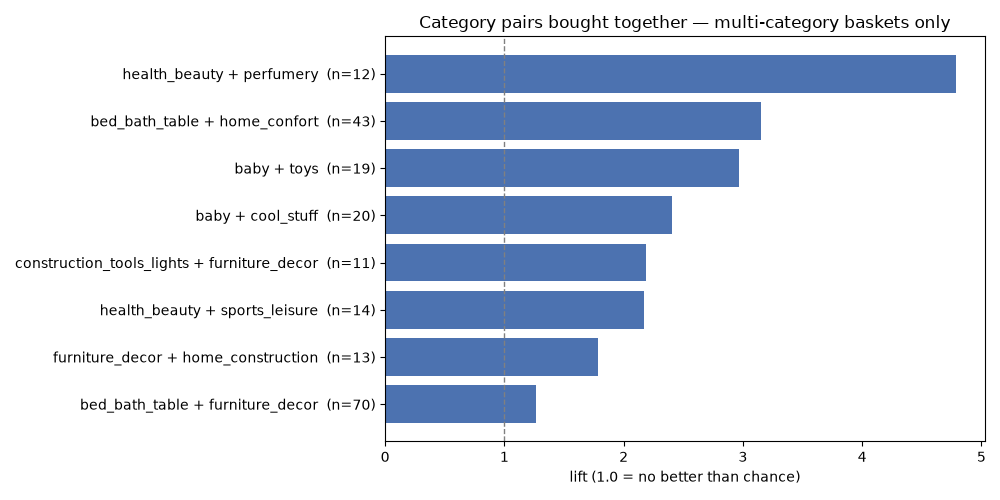

In [6]:
path = save_rules_chart(rules)
Image(path)